# MetalTreeShap quickstart

`metal-treeshap` computes **exact TreeSHAP attributions for XGBoost models on Apple
GPUs** — a Metal port of NVIDIA's GPUTreeShap. This notebook trains a model, compiles a
`MetalTreeExplainer`, verifies the output against XGBoost's own `pred_contribs`, and
plots a first attribution summary.

**Requirements:** Apple Silicon Mac (macOS 13+), plus `xgboost`, `numpy`, and
`matplotlib`. Install the published `metal-treeshap` wheel from PyPI:

```bash
python3 -m pip install metal-treeshap matplotlib xgboost
```

In [1]:
import platform
import warnings

import numpy as np

warnings.filterwarnings("ignore", message="A NumPy version")  # harmless scipy notice
import xgboost as xgb  # noqa: E402  (after the filter, on purpose)

import metal_treeshap  # noqa: E402
from metal_treeshap import MetalTreeExplainer  # noqa: E402

print(f"macOS {platform.mac_ver()[0]} / {platform.machine()}")
print(f"xgboost {xgb.__version__}, numpy {np.__version__}, "
      f"metal-treeshap {metal_treeshap.__version__}")

macOS 26.2 / arm64
xgboost 3.1.2, numpy 2.5.1, metal-treeshap 0.1.0


## Train a model

A synthetic regression with **15% missing values** — XGBoost routes `NaN` through each
node's default branch, and metal-treeshap reproduces that routing exactly.

In [2]:
rng = np.random.default_rng(7)
n_train, n_features = 20_000, 10
X_train = rng.standard_normal((n_train, n_features)).astype(np.float32)
X_train[rng.random(X_train.shape) < 0.15] = np.nan
y = (np.nansum(X_train[:, :4], axis=1)
     + 0.5 * np.nan_to_num(X_train[:, 4]) * np.nan_to_num(X_train[:, 5])
     + 0.1 * rng.standard_normal(n_train))

booster = xgb.train(
    {"objective": "reg:squarederror", "max_depth": 5, "eta": 0.1,
     "tree_method": "hist", "seed": 7},
    xgb.DMatrix(X_train, label=y),
    num_boost_round=100,
)

X = rng.standard_normal((5_000, n_features)).astype(np.float32)
X[rng.random(X.shape) < 0.15] = np.nan
print(f"trained 100 trees, depth 5; explaining {X.shape[0]:,} rows")

trained 100 trees, depth 5; explaining 5,000 rows


## Compile once, explain many

`from_xgboost` accepts a live `Booster`, a saved JSON model path, raw JSON
text/bytes, or a parsed dict. Compilation extracts the decision paths, packs them for
the GPU, and builds the Metal pipelines — pay it once, then reuse the explainer.

In [3]:
explainer = MetalTreeExplainer.from_xgboost(booster)
phis = explainer.shap_values(X)
print(f"phis shape: {phis.shape}  (rows, features + 1; last column is the bias term)")

phis shape: (5000, 11)  (rows, features + 1; last column is the bias term)


## Verify against XGBoost's own attribution

XGBoost's `pred_contribs=True` runs the same exact-TreeSHAP algorithm on the CPU.
The two engines must agree elementwise, and each row of attributions must sum to the
model's margin prediction (*local accuracy*).

In [4]:
dtest = xgb.DMatrix(X)
cpu_phis = booster.predict(dtest, pred_contribs=True)
margin = booster.predict(dtest, output_margin=True)

max_diff = float(np.abs(phis - cpu_phis).max())
additivity = float(np.abs(phis.sum(axis=1) - margin).max())
print(f"max |GPU - CPU| elementwise : {max_diff:.3e}")
print(f"max |sum(phis) - margin|    : {additivity:.3e}")
assert max_diff < 1e-3 and additivity < 1e-3

max |GPU - CPU| elementwise : 5.960e-06
max |sum(phis) - margin|    : 9.298e-06


In [5]:
import matplotlib.pyplot as plt

# Fixed series colors (validated colorblind-safe palette). The assignment follows the
# ENGINE, never the plot order, so every chart in these notebooks reads the same way.
COLORS = {
    "XGBoost CPU": "#2a78d6",          # blue
    "Metal atomic": "#1baf7a",         # aqua
    "Metal deterministic": "#eda100",  # yellow
}
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "axes.titlesize": 12,
    "axes.titleweight": "600",
    "axes.labelcolor": "#3a3a38",
    "text.color": "#3a3a38",
    "xtick.color": "#6b6a66",
    "ytick.color": "#6b6a66",
    "legend.frameon": False,
})

## Mean |SHAP| per feature

The classic global-importance readout: average attribution magnitude across the
explained rows. Features 0–3 carry the additive signal and 4–5 the interaction, so
they should dominate.

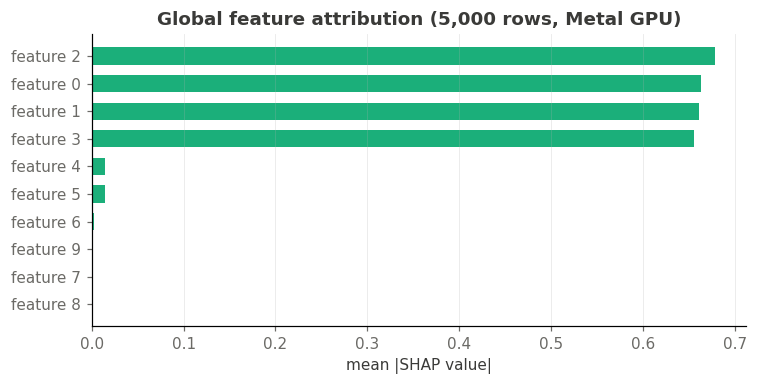

In [6]:
mean_abs = np.abs(phis[:, :-1]).mean(axis=0)
order = np.argsort(mean_abs)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh([f"feature {i}" for i in order], mean_abs[order],
        color=COLORS["Metal atomic"], height=0.62)
ax.set_xlabel("mean |SHAP value|")
ax.set_title("Global feature attribution (5,000 rows, Metal GPU)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## pandas and call introspection

`DataFrame` input is consumed by position (pass columns in training order); nullable
values become `NaN`. Note the comparison below allows a tiny tolerance: the default
**atomic** mode's float additions land in scheduler order, so two runs differ at the
~1e-6 level (deterministic mode makes reruns bit-identical — see notebook 03).
`last_timings` exposes what the most recent call actually did — GPU time, zero-copy
state, and dispatch shape.

In [7]:
import pandas as pd

frame = pd.DataFrame(X, columns=[f"f{i}" for i in range(n_features)]).astype("Float32")
frame_phis = explainer.explain(frame)
delta = float(np.abs(frame_phis - explainer.explain(X)).max())
print(f"max |DataFrame run - ndarray run|: {delta:.2e} (atomic-mode run jitter only)")
assert delta < 1e-4
explainer.last_timings

max |DataFrame run - ndarray run|: 5.72e-06 (atomic-mode run jitter only)


{'upload_s': 6.375e-06,
 'encode_s': 2.525e-05,
 'gpu_s': 0.006004875060170889,
 'total_s': 0.00625775,
 'x_zero_copy': False,
 'output_zero_copy': True,
 'dispatched': True,
 'deterministic_scratch_bytes': 0,
 'deterministic_scratch_capacity_bytes': 0,
 'deterministic_tile_rows': 0,
 'deterministic_tiles': 0,
 'atomic_tile_rows': 5000,
 'atomic_tiles': 1}

---
**Next:** [`02-cpu-vs-gpu-benchmark.ipynb`](02-cpu-vs-gpu-benchmark.ipynb) measures the
CPU/GPU performance gap properly, and
[`03-accumulation-modes.ipynb`](03-accumulation-modes.ipynb) tours the atomic /
deterministic execution modes and tuning knobs.